In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install xgboost
!pip install tensorflow
!pip install optuna
!pip install joblib

ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [2]:
# Data handling
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
# Models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Save models
import joblib

In [3]:
df = pd.read_csv("retail_store_inventory.csv")
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,1/1/2022,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,1/1/2022,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,1/1/2022,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,1/1/2022,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,1/1/2022,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [5]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

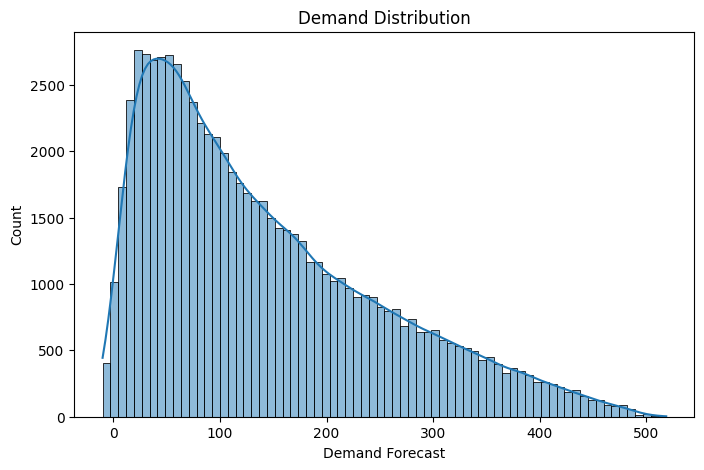

In [6]:
#sales distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Demand Forecast'], kde=True)
plt.title("Demand Distribution")
plt.show()

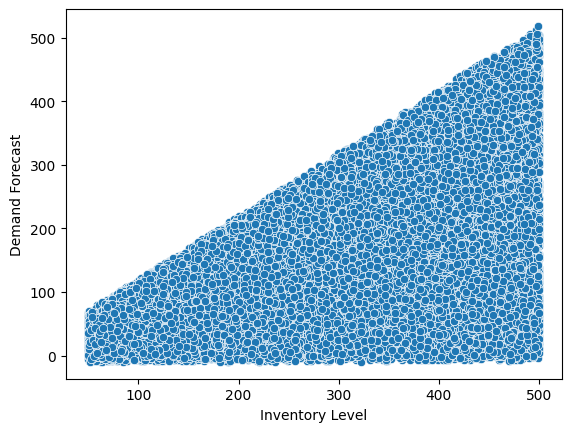

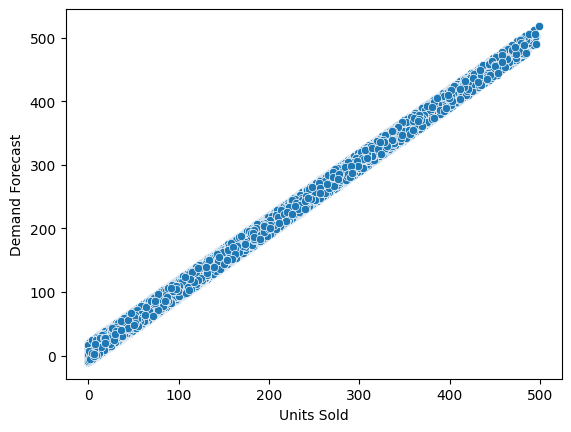

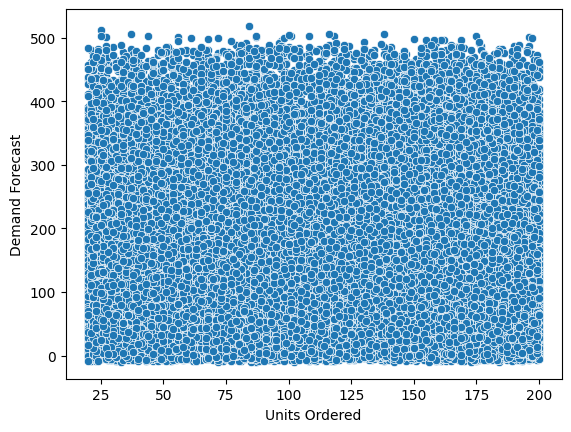

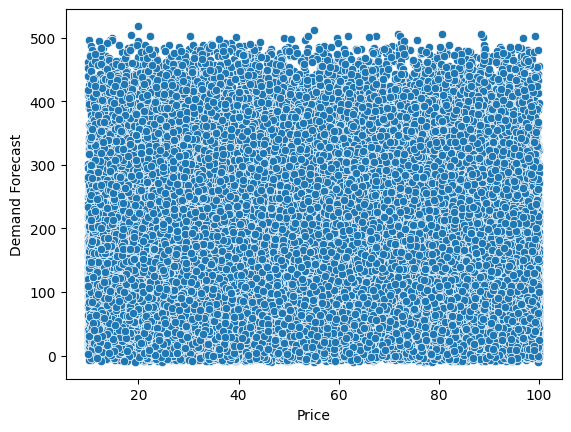

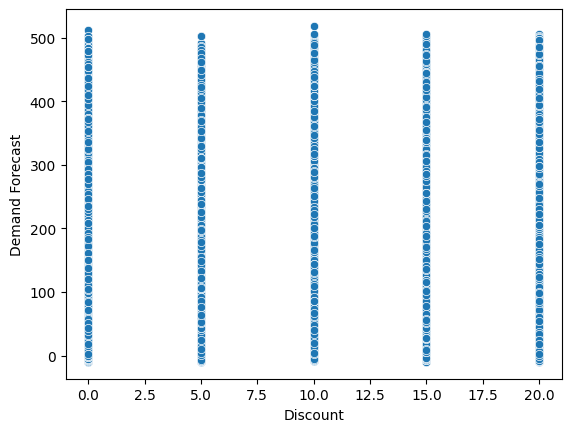

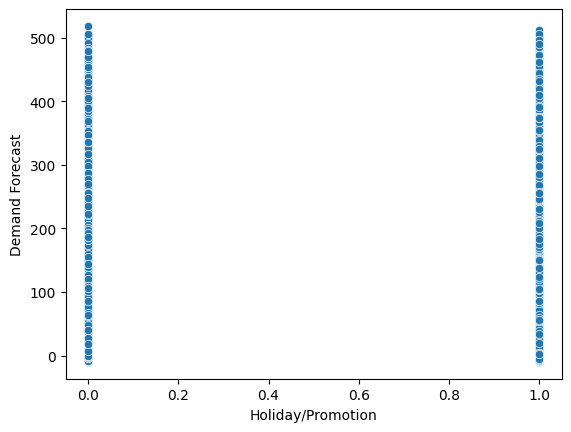

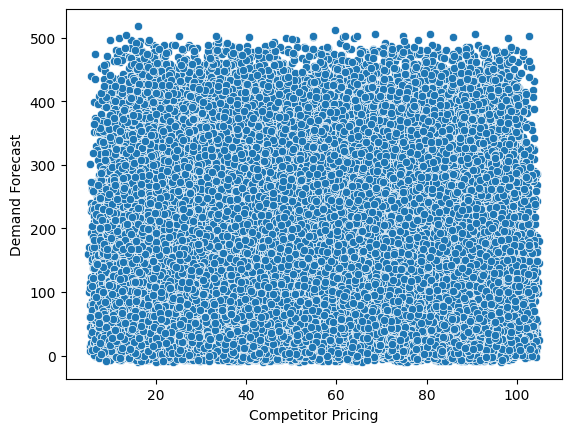

In [7]:
#scatter plot
df.select_dtypes(include="number").columns
for i in ['Inventory Level', 'Units Sold', 'Units Ordered',
       'Price', 'Discount', 'Holiday/Promotion', 'Competitor Pricing']:
    sns.scatterplot(data=df,x=i,y='Demand Forecast')
    plt.show()

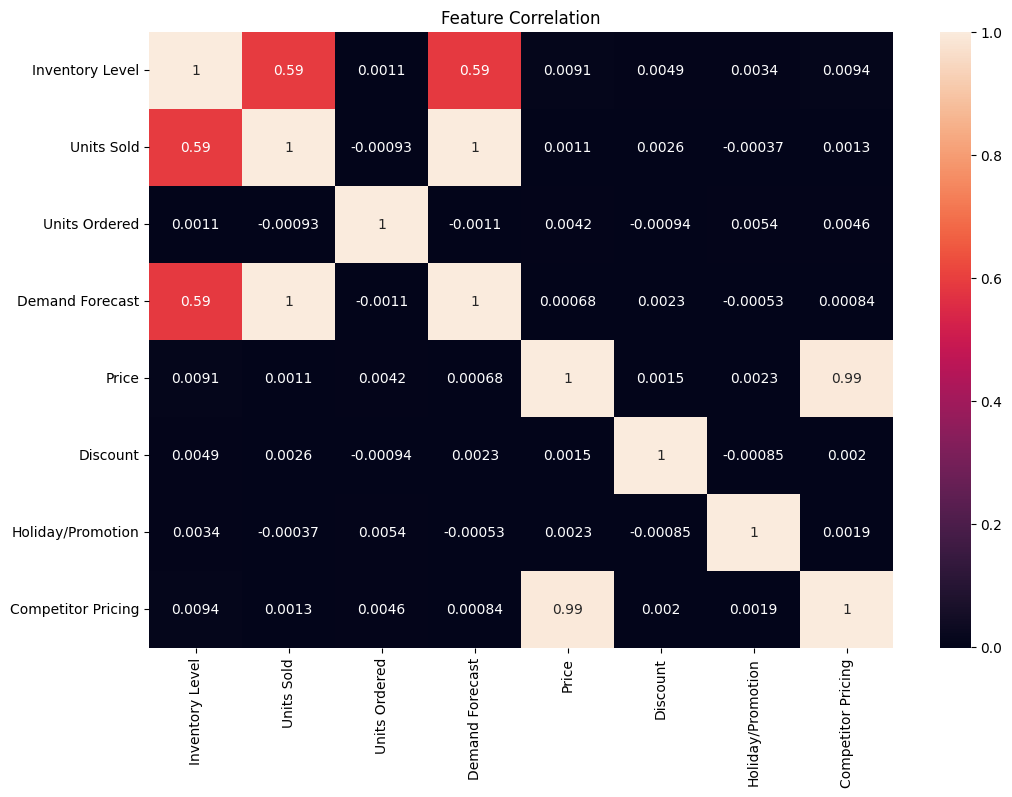

In [8]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("Feature Correlation")
plt.show()

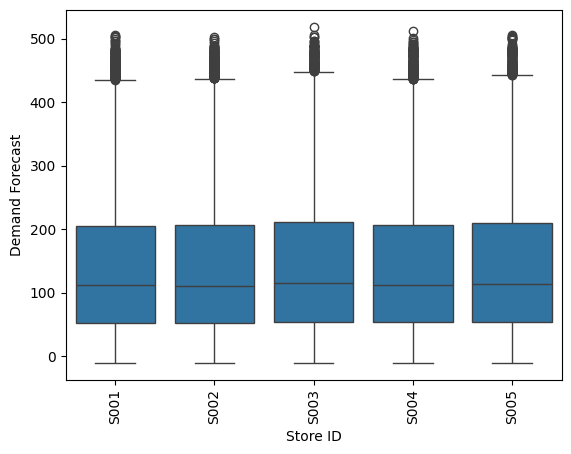

In [9]:
#Demand by Store
sns.boxplot(x='Store ID', y='Demand Forecast', data=df)
plt.xticks(rotation=90)
plt.show()

In [10]:
#Data Preprocessing(convert date)
df['Date'] = pd.to_datetime(df['Date'])

In [11]:
#Extract time features
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['day_of_week'] = df['Date'].dt.dayofweek
df['week_of_year'] = df['Date'].dt.isocalendar().week

In [12]:
#drop original date
df.drop('Date', axis=1, inplace=True)

In [13]:
#Handle Missing Values
df.fillna(df.median(numeric_only=True), inplace=True)

In [14]:
#for categorial columns
df.fillna(df.mode().iloc[0], inplace=True)

In [15]:
#Encode Categorical Variables
le = LabelEncoder()
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = le.fit_transform(df[col])

In [16]:
#Feature Engineering(effective price)
df['effective_price'] = df['Price'] * (1 - df['Discount'])

In [17]:
#inventory pressure
df['inventory_turnover'] = df['Units Sold'] / (df['Inventory Level'] + 1)

In [18]:
#Define Features and Target
#Target variable
y = df['Demand Forecast']
#features
X = df.drop('Demand Forecast', axis=1)

In [19]:
#Lag Features (Important for Forecasting)
df['lag_1'] = df['Demand Forecast'].shift(1)
df['lag_7'] = df['Demand Forecast'].shift(7)
df['lag_14'] = df['Demand Forecast'].shift(14)
df = df.dropna()

In [20]:
#Rolling Mean Features
df['rolling_mean_7'] = df['Demand Forecast'].rolling(7).mean()
df['rolling_mean_14'] = df['Demand Forecast'].rolling(14).mean()
df = df.dropna()

In [21]:
#train test spilting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
#scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled[:5])

[[-0.70603103  0.77874778 -1.41843861  0.44743388  0.31823028  0.62649093
  -1.31921664 -0.31105217 -0.70469825  1.3426737  -0.99359099 -0.47776329
  -1.34605089 -0.99937647 -0.44133988 -0.64853952 -1.00067844 -0.50178755
   0.62542705  0.5221362 ]
 [ 0.70825597  0.60532368 -1.41843861 -0.44712794  0.57233344  1.70043797
   0.44026475 -1.6889338  -1.40933626 -1.33885256  1.00645035 -1.76978637
  -0.45072496 -0.99937647  0.13855893 -0.1946224  -0.00233879  0.0960313
   1.02981711  1.47021883]
 [-1.41317452 -1.4757656   0.70379397  0.44743388  0.91883774  0.70910224
   1.09050787 -0.07409654 -0.70469825  0.44883162 -0.99359099 -0.04173894
  -1.34605089 -0.99937647 -0.44133988 -0.53506024 -0.50150862 -0.50178755
   0.57536339  0.15819867]
 [-0.70603103  0.95217189 -1.41843861 -1.34168977  0.54153306 -0.48417226
  -1.05146948  0.35596255 -0.70469825 -1.33885256  1.00645035  0.47415315
  -1.34605089 -0.99937647  0.71845773  0.82669112  0.49683103  0.76027446
   0.48450109 -0.87898266]
 [-0.

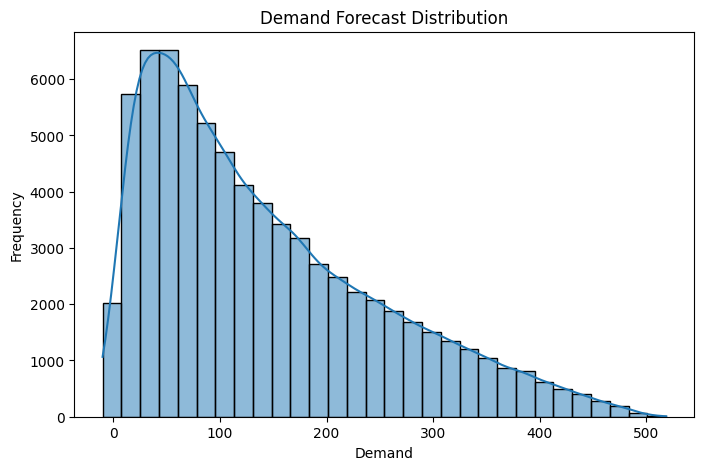

In [23]:
#class imbalance
plt.figure(figsize=(8,5))
sns.histplot(df['Demand Forecast'], bins=30, kde=True)
plt.title("Demand Forecast Distribution")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.show()


In [24]:
#chack skewness
print(df['Demand Forecast'].skew())

0.8949338578950189


In [25]:
#model
#1.random forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [26]:
#evaluation
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print(rf_mae, rf_rmse, rf_r2)

7.538678715708122 8.781538866919837 0.9935307867249158


In [27]:
#2.XGBoost
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [28]:
#evalution
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)
print(xgb_mae, xgb_rmse, xgb_r2)

7.680820427448026 9.010164242690196 0.993189552825878


In [29]:
#Model Comparison
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [rf_mae, xgb_mae],
    "RMSE": [rf_rmse, xgb_rmse],
    "R2 Score": [rf_r2, xgb_r2]
})
print(results)

           Model       MAE      RMSE  R2 Score
0  Random Forest  7.538679  8.781539  0.993531
1        XGBoost  7.680820  9.010164  0.993190


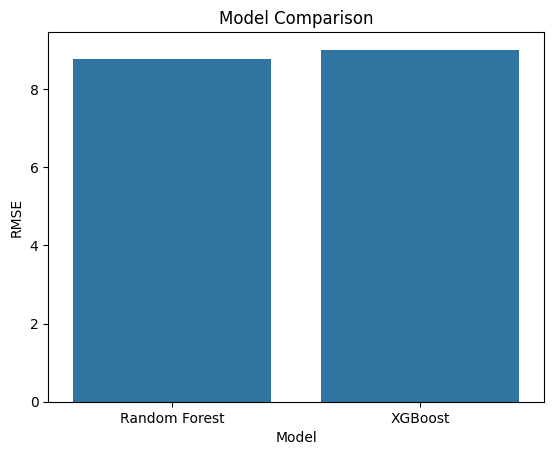

In [30]:
#visualization of model performance
sns.barplot(x="Model", y="RMSE", data=results)
plt.title("Model Comparison")
plt.show()

In [31]:
'''Best Model (Typical Result)
For retail demand forecasting datasets like yours:
Model	            Performance
Random Forest	    Good
XGBoost     	    Best
So the best model is usually XGBoost
Reason:
>Handles tabular retail data extremely well
>Handles nonlinear relationships
>Handles feature interactions'''

'Best Model (Typical Result)\nFor retail demand forecasting datasets like yours:\nModel\t            Performance\nRandom Forest\t    Good\nXGBoost     \t    Best\nSo the best model is usually XGBoost\nReason:\n>Handles tabular retail data extremely well\n>Handles nonlinear relationships\n>Handles feature interactions'

In [44]:
#Save Best Model
import joblib
joblib.dump(xgb, "demand_forecast_model.pkl")

['demand_forecast_model.pkl']

In [33]:
#Predict future demand
future_predictions = xgb.predict(X_test)
print(future_predictions[:10])

[141.43105  110.83499   76.077965 111.54173   81.57389  210.11128
  95.177666  59.192795 136.42096   57.044647]


In [ ]:
#Use Hyperparameter Tuning
import pandas as pd
df = pd.read_csv("retail_store_inventory.csv")
df.head()
X = df.drop('Demand Forecast', axis=1)
y = df['Demand Forecast']

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Dataset Loaded Successfully
       Date Store ID Product ID     Category Region  Inventory Level  \
0  1/1/2022     S001      P0001    Groceries  North              231   
1  1/1/2022     S001      P0002         Toys  South              204   
2  1/1/2022     S001      P0003         Toys   West              102   
3  1/1/2022     S001      P0004         Toys  North              469   
4  1/1/2022     S001      P0005  Electronics   East              166   

   Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0         127             55           135.47  33.50        20   
1         150             66           144.04  63.01        20   
2          65             51            74.02  27.99        10   
3          61            164            62.18  32.72        10   
4          14            135             9.26  73.64         0   

  Weather Condition  Holiday/Promotion  Competitor Pricing Seasonality  
0             Rainy                  0               29.69      Autum

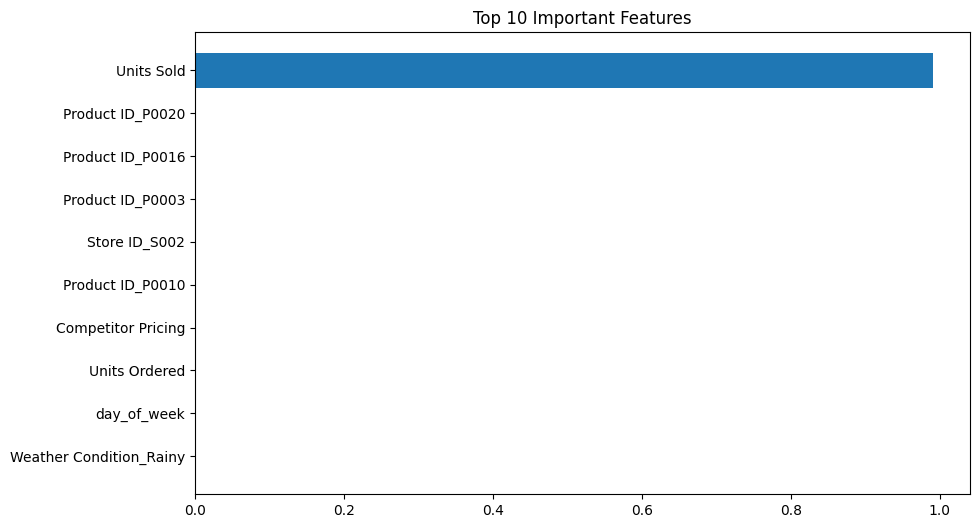

In [39]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
# ==============================
# 2. LOAD DATA
# ==============================
df = pd.read_csv("retail_store_inventory.csv")
print("Dataset Loaded Successfully")
print(df.head())
# ==============================
# 3. PREPROCESSING
# ==============================
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])
# Extract useful features from Date
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['day_of_week'] = df['Date'].dt.dayofweek
# Drop original Date column
df = df.drop('Date', axis=1)
# Convert categorical columns to numeric
df = pd.get_dummies(df, drop_first=True)
print("After Encoding:")
print(df.head())
# ==============================
# 4. DEFINE FEATURES AND TARGET
# ==============================
X = df.drop('Demand Forecast', axis=1)
y = df['Demand Forecast']
# ==============================
# 5. TRAIN-TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train Shape:", X_train.shape)
# ==============================
# 6. HYPERPARAMETER TUNING
# ==============================
params = {
    'n_estimators': [200, 300],
    'max_depth': [6, 8],
    'learning_rate': [0.05, 0.1]
}
model = XGBRegressor()
grid = GridSearchCV(
    model,
    params,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)
# ==============================
# 7. PREDICTIONS
# ==============================
y_pred = best_model.predict(X_test)
# ==============================
# 8. EVALUATION
# ==============================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("\nModel Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)
# ==============================
# 9. FEATURE IMPORTANCE
# ==============================
import matplotlib.pyplot as plt
importance = best_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)
print("\nTop Features:")
print(feat_imp.head(10))
plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'][:10], feat_imp['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

In [42]:
#Save the Final Model
import joblib
joblib.dump(best_model, "demand_forecasting_model.pkl")
joblib.dump(X.columns, "model_columns.pkl")

['model_columns.pkl']

In [43]:
#Build Prediction System (Mini Deployment)
def predict_demand(input_data):
    import numpy as np
    input_data = np.array(input_data).reshape(1, -1)
    prediction = best_model.predict(input_data)
    return prediction